In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Implementation of a Full-Quantum-Boltzmann-Machine (QRBM) on Dynex

Implementation of the Quantum-Boltzmann-Machine (QRBM), utilising Dynex' Neuromorphic Computing platform. All training samples are being sampled on the Dynex platform with no Gibbs or CD steps (full QRBM). It is based on https://cmst.eu/articles/applying-a-quantum-annealing-based-restricted-boltzmann-machine-for-mnist-handwritten-digit-classification/

1. sampling probabilities of hidden units on the Dynex platform
2. sampling reconstruction v' from visible units on the Dynex platform
3. resampling hidden activations h' from v' on the Dynex platform

After each training batch (or as configured), a training sample is reconstructed with the Dynex platform and the MSE measured:

- reconstructing data to calculate MSE on the Dynex platform

This approach converges extremely fast to a low MSE. The size of the training samples is almost unlimited, but keep in mind that each data sample is being sampled on the Dynex platform.

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:

from dynex import DynexConfig, ComputeBackend, QPUModel

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model=QPUModel.APOLLO_RC1, use_notebook_output=True)


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [ ]:
import os, pickle
import numpy as np

def _prepare_mnist():
    os.makedirs("datasets", exist_ok=True)
    need_pickle = not os.path.exists("datasets/MNIST.pickle")
    need_csv    = not os.path.exists("datasets/mnist_train.csv")
    if not need_pickle and not need_csv:
        print("MNIST dataset already present")
        return
    print("Downloading MNIST via scikit-learn (one-time, ~15MB)...")
    from sklearn.datasets import fetch_openml
    import pandas as pd
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X = mnist.data.astype(np.float32) / 255.0
    y = mnist.target.astype(np.int32)
    split = 60000
    if need_pickle:
        with open("datasets/MNIST.pickle", "wb") as f:
            pickle.dump((X[:split], y[:split]), f)
        with open("datasets/MNIST_test.pickle", "wb") as f:
            pickle.dump((X[split:], y[split:]), f)
        print("Saved MNIST.pickle / MNIST_test.pickle")
    if need_csv:
        train = pd.DataFrame(X[:split])
        train.insert(0, "label", y[:split])
        train.to_csv("datasets/mnist_train.csv", index=False)
        test = pd.DataFrame(X[split:])
        test.insert(0, "label", y[split:])
        test.to_csv("datasets/mnist_test.csv", index=False)
        print("Saved mnist_train.csv / mnist_test.csv")

_prepare_mnist()


In [18]:
import os, ssl, pickle
import numpy as np

os.makedirs("datasets", exist_ok=True)

if not os.path.exists("datasets/MNIST.pickle") or not os.path.exists("datasets/MNIST_test.pickle"):
    ssl._create_default_https_context = ssl._create_unverified_context
    import torchvision

    train = torchvision.datasets.MNIST(root="datasets/raw", train=True, download=True)
    test = torchvision.datasets.MNIST(root="datasets/raw", train=False, download=True)


    def to_dict(dataset):
        data = {}
        pixels = dataset.data.numpy().reshape(len(dataset), -1) / 255.0
        labels = dataset.targets.numpy()
        for digit in range(10):
            data[digit] = pixels[labels == digit].tolist()
        return data


    pickle.dump(to_dict(train), open("datasets/MNIST.pickle", "wb"))
    pickle.dump(to_dict(test), open("datasets/MNIST_test.pickle", "wb"))
    print("MNIST pickle files created")
else:
    print("MNIST pickle files already exist")

MNIST pickle files already exist


In [19]:
# load MNIST data:
MNIST = pickle.load(open("datasets/MNIST.pickle", "rb"))
MNIST_test = pickle.load(open("datasets/MNIST_test.pickle", "rb"))

In [20]:
digits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
X = []
y = []
y_class = []
for digit in digits:
    for img in MNIST[digit]:
        X.append(img)
        labels = [0] * len(digits)  # labels are converted into binary values of len(labels)
        labels[digit] = 1
        y.append(labels)
        y_class.append(digit)

X_val = []
y_val = []
y_val_class = []

for digit in digits:
    for img in MNIST_test[digit]:
        X_val.append(img)
        labels = [0] * len(digits)  # labels are converted into binary values of len(labels)
        labels[digit] = 1
        y_val.append(labels)
        y_val_class.append(digit)

X = np.array(X)
X_val = np.array(X_val)
y = np.array(y)
y_val = np.array(y_val)
print("training data:", X.shape, "labels:", y.shape, "validation data:", X_val.shape, "labels:", y_val.shape)


training data: (60000, 784) labels: (60000, 10) validation data: (10000, 784) labels: (10000, 10)


## Setting up the QRBM

In [21]:
from utils import QRBM

qrbm = QRBM.DYNEX_QRBM(n_visible=X.shape[1] + y.shape[1],  # features + labels
                       n_hidden=300,  #160,
                       num_reads=50000,  #100,
                       annealing_time=2000,  #False, 
                       minimum_stepsize=0.00000006,
                       logging=False,
                       debugging=False,
                       seed=50390,
                       description="Dynex SDK Job"
                       )

SEED SET TO 50390


## Training

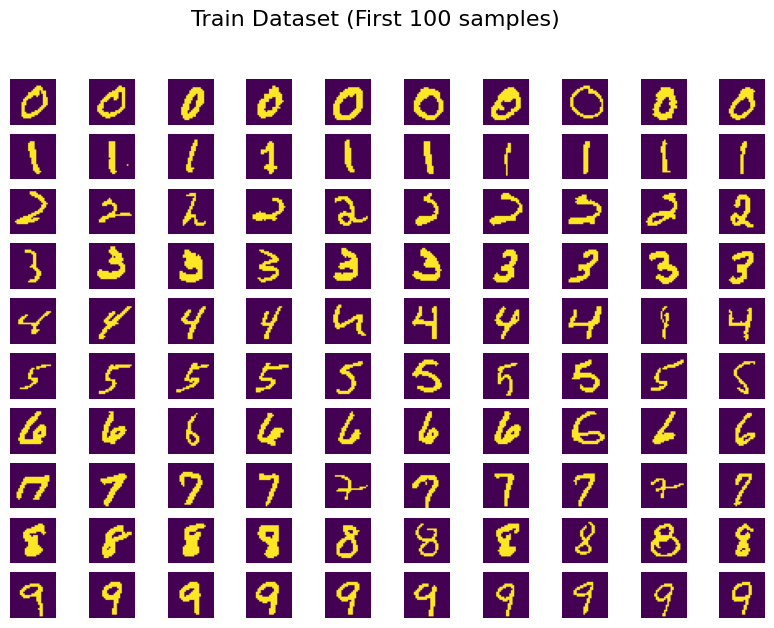

In [22]:
trainlength = 10

X_one = np.vstack((np.array(X[:trainlength]),
                   np.array(X[7000:7000 + trainlength]),
                   np.array(X[14000:14000 + trainlength]),
                   np.array(X[21000:21000 + trainlength]),
                   np.array(X[28000:28000 + trainlength]),
                   np.array(X[35000:35000 + trainlength]),
                   np.array(X[40000:40000 + trainlength]),
                   np.array(X[45000:45000 + trainlength]),
                   np.array(X[49000:49000 + trainlength]),
                   np.array(X[57000:57000 + trainlength]),
                   ))

y_one = np.vstack((np.array(y[:trainlength]),
                   np.array(y[7000:7000 + trainlength]),
                   np.array(y[14000:14000 + trainlength]),
                   np.array(y[21000:21000 + trainlength]),
                   np.array(y[28000:28000 + trainlength]),
                   np.array(y[35000:35000 + trainlength]),
                   np.array(y[40000:40000 + trainlength]),
                   np.array(y[45000:45000 + trainlength]),
                   np.array(y[49000:49000 + trainlength]),
                   np.array(y[57000:57000 + trainlength]),
                   ))

fig = plt.figure(figsize=(10, 7))
fig.suptitle("Train Dataset (First 100 samples)", fontsize=16)
rows = 10
columns = 10

for j in range(0, 100):
    fig.add_subplot(rows, columns, j + 1)
    plt.imshow(X_one[j].reshape(28, -1))
    plt.axis("off")

plt.show()

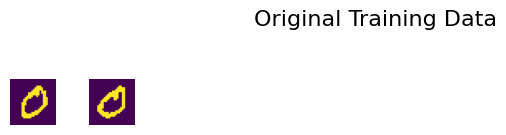

In [23]:
# test images:
trainlength = 2
X_one = np.vstack((np.array(X[:trainlength])
                   ))
y_one = np.vstack((np.array(y[:trainlength])
                   ))

fig = plt.figure(figsize=(10, 7))
fig.suptitle("Original Training Data", fontsize=16)
rows = 10
columns = 10

for j in range(0, len(X_one)):
    fig.add_subplot(rows, columns, j + 1)
    plt.imshow(X_one[j].reshape(28, -1))
    plt.axis("off")

plt.show()

With this model, each training sample is being sampled on the Dynex Platform (as described above). We can define a training stop once a certain level of MSE is being reached (stop_at_mse = 0.0). We can also define how often the MSE is being updated (each MSE calculation requires one sampling step on the Dynex platform (mse_every_epochs = 1).

In [24]:
qrbm.train(
    training_data=X_one,
    training_labels=y_one,
    epochs=10,
    lr=0.1,
    lr_decay=0.1,
    epoch_drop=None,  # default epochs/5 drops learning rate every X training steps
    momentum=0,  #  Let the update to the weight matrix W be the positive gradient minus the negative gradient
    batch_size=trainlength,
    # should equal number of train samples in parallel environment all samples are processed in one batch together
    autosave=False,
    stop_at_mse=0.0,
    plot_reconstructed_images=False,
    mse_every_epochs=1  # every x epochs the MSE is calculated (needs QUBO)
)

INFO: [DYNEX-CPU] No valid sample result found. Resampling... 10 / 10
100%|██████████| 10/10 [23:41<00:00, 142.19s/it, MSE=0.179, MSE(best)=0.179, INFO=]                                   


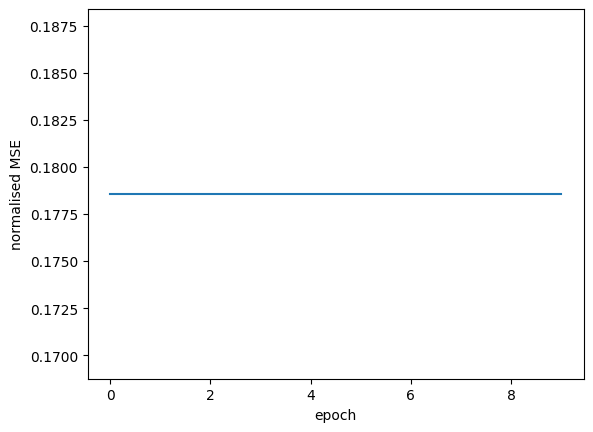

[np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858), np.float64(0.17857142857142858)]


In [25]:
#plot
plt.figure()
plt.plot(qrbm.mse)
plt.xlabel("epoch")
plt.ylabel("normalised MSE")
plt.show()
print(qrbm.mse)

## Reconstruct and Predict with QUBO

In [26]:
pred_data, pred_labels = qrbm.generate(X_one[0])

INFO: [DYNEX-CPU] No valid sample result found. Resampling... 10 / 10


predicted labels= [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
mse =  0.16581632653061223


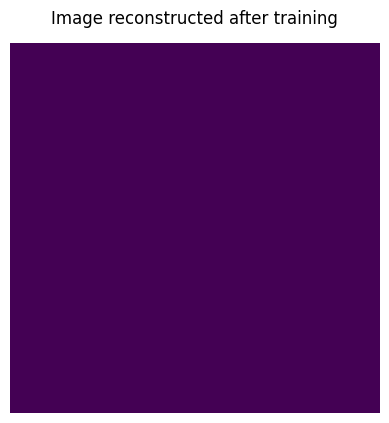

In [27]:
plt.figure()
plt.axis("off")
plt.title("Image reconstructed after training", y=1.03)
plt.imshow(np.array(pred_data).reshape(28, -1))
print("predicted labels=", pred_labels)
mse = np.sum((np.array(X_one[0]) - np.array(pred_data)) ** 2) / (qrbm.num_features)  # normalized
print("mse = ", mse)

## Predict with Contrastive Divergence Infer

In [28]:
predictions, _ = qrbm.predict(X_one, num_particles=100, num_gibbs_updates=10)
predictions = pd.DataFrame(predictions, columns=digits)
predictions

,0,1,2,3,4,5,6,7,8,9
0,0.992419,0.006853,0.010602,0.967389,0.392619,0.998114,0.995595,0.999964,0.002879,0.000005
1,0.999254,0.010122,0.092742,0.109597,0.005427,0.999137,0.999319,0.999962,0.000231,0.010207


In [29]:
m = np.zeros_like(predictions.values)
m[np.arange(len(predictions)), predictions.values.argmax(1)] = 1
pd.DataFrame(m, columns=predictions.columns).astype(int)

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,1,0,0


## Reconstruct features

In [30]:
_, features = qrbm.predict(X_one, num_particles=100, num_gibbs_updates=1)

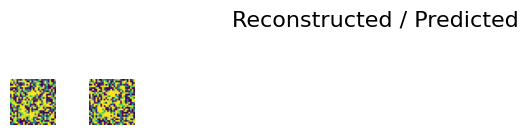

In [31]:
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Reconstructed / Predicted", fontsize=16)
rows = 10
columns = 10

for j in range(0, len(features)):
    fig.add_subplot(rows, columns, j + 1)
    plt.imshow(features[j].reshape(28, -1))
    #marker=str(y_one[j])
    #plt.title(marker)
    plt.axis("off")

plt.show()

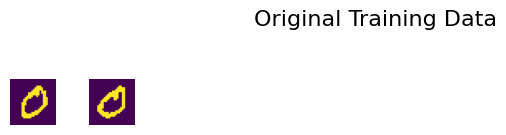

In [32]:
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Original Training Data", fontsize=16)
rows = 10
columns = 10

for j in range(0, len(X_one)):
    fig.add_subplot(rows, columns, j + 1)
    plt.imshow(X_one[j].reshape(28, -1))
    plt.axis("off")

plt.show()

## Save Model

In [33]:
qrbm.save("model.bin")

## Load Model

In [34]:
qrbm.load(filename="model.bin")

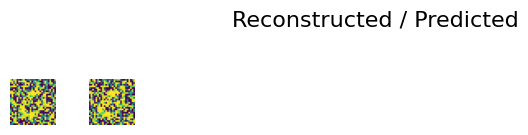

In [35]:
_, features = qrbm.predict(X_one, num_particles=100, num_gibbs_updates=1)
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Reconstructed / Predicted", fontsize=16)
rows = 10
columns = 10

for j in range(0, len(features)):
    fig.add_subplot(rows, columns, j + 1)
    plt.imshow(features[j].reshape(28, -1))
    #marker=str(y_one[j])
    #plt.title(marker)
    plt.axis("off")

plt.show()